# LSTM Sequence Recommendation Training and Evaluation

This notebook demonstrates how to train and evaluate the 5-layer LSTM model for sequence prediction recommendations.

In [1]:
import os
import sys
import django

# Setup Django environment
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../ai-service'))
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'recommender_ai_service.settings')

# Configure database connection details for local development outside Docker
os.environ['DB_HOST'] = '127.0.0.1'
os.environ['DB_NAME'] = 'bookstore_ai'

# Allow synchronous operations in Jupyter's async context
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = 'true'

django.setup()


AI-Service background bootstrap sync will start in 15 seconds...


AI-Service background bootstrap sync starting...
ProductNode database already contains records. Skipping bootstrap sync.
Initializing SentenceTransformer encoder...


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


FAISS index successfully rebuilt with 24 items!
FAISS index successfully rebuilt with 24 items!


In [2]:
import torch
import matplotlib.pyplot as plt
from app.models import UserBehavior
from app.lstm_model import train_lstm_model, get_lstm_recommendations, get_model_path

# 1. Fetch current behavior logs
behaviors = list(UserBehavior.objects.all())
print(f"Total user behavior records in database: {len(behaviors)}")

Total user behavior records in database: 9


Training the LSTM model...
Not enough user behavior data for training. Seeding synthetic sequence data...
Epoch 1/10 Loss: 6.9221
Epoch 2/10 Loss: 6.5628
Epoch 3/10 Loss: 4.5536
Epoch 4/10 Loss: 3.1732
Epoch 5/10 Loss: 2.8843
Epoch 6/10 Loss: 2.7844
Epoch 7/10 Loss: 2.7026
Epoch 8/10 Loss: 2.6326
Epoch 9/10 Loss: 2.5447
Epoch 10/10 Loss: 2.4759
LSTM model saved successfully to C:\Users\Admin\Desktop\PTIT\Y4_T2\SoftwareArchitectureAndDesign\bookstore-microservice\ai-service\data\lstm_model.pt!


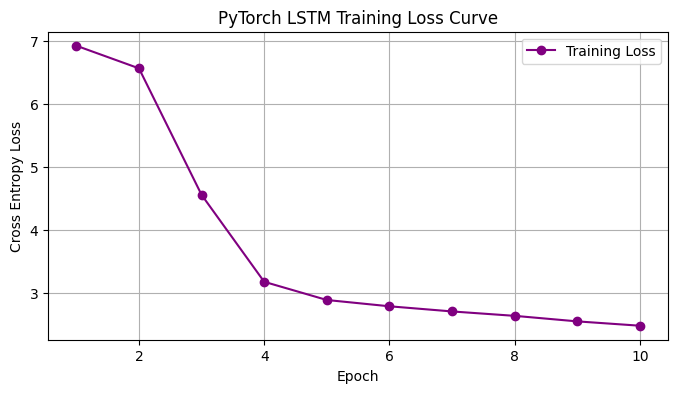

In [3]:
# 2. Train the model (will output loss curves)
print("Training the LSTM model...")
epochs = 10
model, losses = train_lstm_model(behaviors, num_epochs=epochs, return_losses=True)

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), losses, marker='o', color='purple', label='Training Loss')
plt.title('PyTorch LSTM Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.grid(True)
plt.legend()
plt.show()

In [4]:
# 3. Run model training wrapper
print(f"Model saved to: {get_model_path()}")

Model saved to: C:\Users\Admin\Desktop\PTIT\Y4_T2\SoftwareArchitectureAndDesign\bookstore-microservice\ai-service\data\lstm_model.pt


In [5]:
# 4. Validate predictions for user 7
history = [1, 2, 3, 4, 5]
recs = get_lstm_recommendations(user_id=7, user_history=history, limit=5)
print("Top 5 Recommendations:")
for idx, (pid, score) in enumerate(recs):
    print(f"{idx+1}. Product ID: {pid} (Probability Score: {score:.4f})")

Top 5 Recommendations:
1. Product ID: 23 (Probability Score: 0.1153)
2. Product ID: 18 (Probability Score: 0.1060)
3. Product ID: 22 (Probability Score: 0.0767)
4. Product ID: 19 (Probability Score: 0.0740)
5. Product ID: 20 (Probability Score: 0.0707)
